<a href="https://colab.research.google.com/github/huyismyname/ET4248_MLiHC_176336_Group_3/blob/gd2-dataset-eda/EDA_EyeQ_Milestone1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 EDA EyeQ — Milestone 1 (Đề tài 2.7)

**Cách dùng:** Bấm menu **Runtime → Run all** (hoặc chạy từng ô từ trên xuống).
Notebook này **không cần Kaggle** cho phần chính — nó tự tải file nhãn EyeQ từ GitHub.

Nó sẽ tạo các biểu đồ cho báo cáo Milestone 1:
1. Phân bố nhãn Good / Usable / Reject (mức độ mất cân bằng)
2. So sánh tập Train và Test
3. Phân tích theo bệnh nhân (bằng chứng vì sao phải chia patient-level)

Mọi biểu đồ được lưu vào thư mục `outputs/` — tải về để dán vào slide/báo cáo.

In [1]:
# Ô 1 — Chuẩn bị thư viện & thư mục
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs('outputs', exist_ok=True)
RED, ORANGE, GREEN = '#C00000', '#E8A33D', '#2E7D32'
print('OK — sẵn sàng.')

OK — sẵn sàng.


## Bước 1 — Tải nhãn EyeQ (tự động, không cần Kaggle)
EyeQ có sẵn nhãn chất lượng cho từng ảnh: **0 = Good, 1 = Usable, 2 = Reject**.
Tên ảnh dạng `10009_left.jpeg` → số đầu (`10009`) là **mã bệnh nhân**, `left/right` là **mắt**.

In [2]:
# Ô 2 — Đọc 2 file nhãn từ GitHub
base = 'https://raw.githubusercontent.com/HzFu/EyeQ/master/data/'
train = pd.read_csv(base + 'Label_EyeQ_train.csv', index_col=0)
test  = pd.read_csv(base + 'Label_EyeQ_test.csv',  index_col=0)

qmap = {0: 'Good', 1: 'Usable', 2: 'Reject'}
for df in (train, test):
    df['quality_name'] = df['quality'].map(qmap)
    df['patient_id']  = df['image'].str.split('_').str[0]   # tách mã bệnh nhân

train['split'] = 'Train'
test['split']  = 'Test'
alldf = pd.concat([train, test], ignore_index=True)

print(f'Train: {len(train):,} ảnh | Test: {len(test):,} ảnh | Tổng: {len(alldf):,} ảnh')
alldf.head()

Train: 12,543 ảnh | Test: 16,249 ảnh | Tổng: 28,792 ảnh


,image,quality,DR_grade,quality_name,patient_id,split
0,10009_left.jpeg,0,0,Good,10009,Train
1,10009_right.jpeg,0,0,Good,10009,Train
2,10014_left.jpeg,2,0,Reject,10014,Train
3,10014_right.jpeg,2,0,Reject,10014,Train
4,10015_left.jpeg,0,0,Good,10015,Train


## Bước 2 — Phân bố nhãn (mất cân bằng)
Đây là biểu đồ quan trọng nhất của Milestone 1: có bao nhiêu ảnh mỗi loại chất lượng.

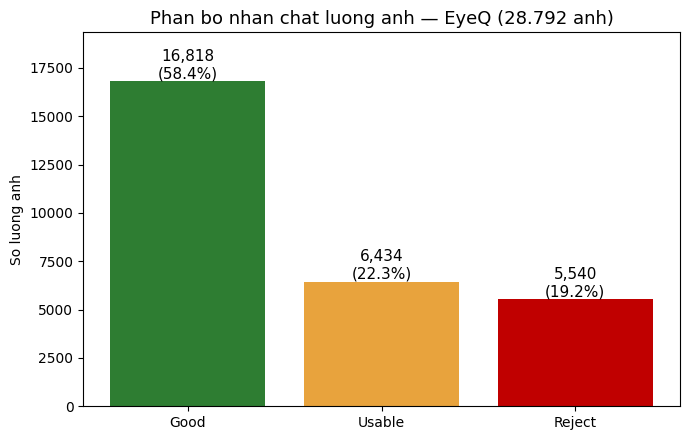

NHẬN XÉT:
- Dữ liệu MẤT CÂN BẰNG: Good chiếm 58.4%, còn Reject chỉ 19.2%.
- Vì mất cân bằng, KHÔNG dùng Accuracy làm độ đo chính (ghi vào báo cáo).


In [3]:
# Ô 3 — Biểu đồ cột: số ảnh mỗi lớp (toàn bộ dữ liệu)
order = ['Good', 'Usable', 'Reject']
counts = alldf['quality_name'].value_counts().reindex(order)
pct = (counts / counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(order, counts.values, color=[GREEN, ORANGE, RED])
for b, c, p in zip(bars, counts.values, pct.values):
    ax.text(b.get_x() + b.get_width()/2, c, f'{c:,}\n({p}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('Phan bo nhan chat luong anh — EyeQ (28.792 anh)', fontsize=13)
ax.set_ylabel('So luong anh'); ax.set_ylim(0, counts.max()*1.15)
plt.tight_layout(); plt.savefig('outputs/01_phan_bo_nhan.png', dpi=150); plt.show()

print('NHẬN XÉT:')
print(f'- Dữ liệu MẤT CÂN BẰNG: Good chiếm {pct["Good"]}%, còn Reject chỉ {pct["Reject"]}%.')
print('- Vì mất cân bằng, KHÔNG dùng Accuracy làm độ đo chính (ghi vào báo cáo).')

## Bước 3 — So sánh Train và Test

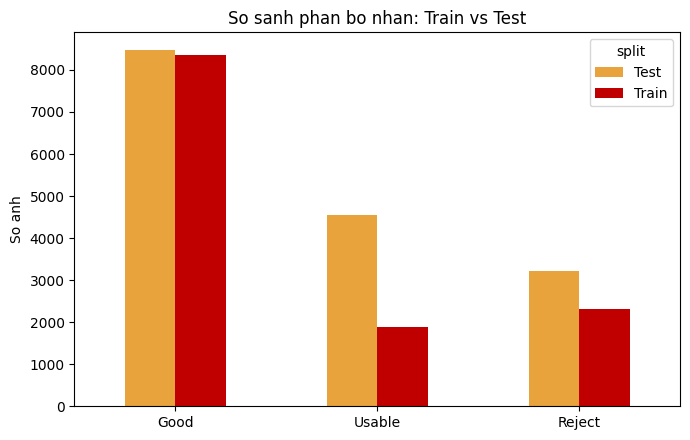

split         Test  Train
quality_name             
Good          8471   8347
Usable        4558   1876
Reject        3220   2320


In [4]:
# Ô 4 — Biểu đồ cột nhóm: Train vs Test
ct = alldf.groupby(['quality_name', 'split']).size().unstack().reindex(order)
ax = ct.plot(kind='bar', figsize=(7, 4.5), color={'Train': RED, 'Test': ORANGE})
ax.set_title('So sanh phan bo nhan: Train vs Test'); ax.set_xlabel(''); ax.set_ylabel('So anh')
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig('outputs/02_train_vs_test.png', dpi=150); plt.show()
print(ct)

## Bước 4 — Phân tích theo bệnh nhân (chống rò rỉ dữ liệu)
Một bệnh nhân có 2 mắt → nhiều ảnh. Nếu để ảnh của **cùng một bệnh nhân** rơi vào
cả Train và Test thì mô hình "học lỏm" → **rò rỉ dữ liệu**. Đây là bằng chứng cho thấy
phải chia tập theo bệnh nhân (patient-level), sẽ làm ở Milestone 2.

Tổng số ảnh:        28,792
Tổng số bệnh nhân:  20,662
Trung bình ảnh/bệnh nhân: 1.39
Số bệnh nhân có ảnh ở >1 mức chất lượng: 1,001

=> KẾT LUẬN: phải chia tập theo patient_id (không chia ngẫu nhiên theo ảnh).


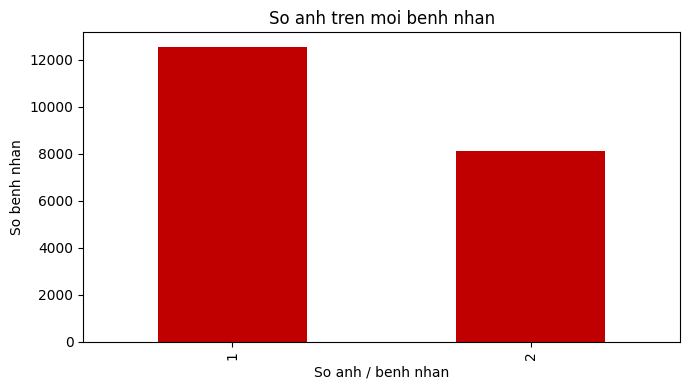

In [5]:
# Ô 5 — Thống kê theo bệnh nhân
n_patients = alldf['patient_id'].nunique()
imgs_per_patient = alldf.groupby('patient_id').size()
multi_quality = alldf.groupby('patient_id')['quality_name'].nunique()

print(f'Tổng số ảnh:        {len(alldf):,}')
print(f'Tổng số bệnh nhân:  {n_patients:,}')
print(f'Trung bình ảnh/bệnh nhân: {imgs_per_patient.mean():.2f}')
print(f'Số bệnh nhân có ảnh ở >1 mức chất lượng: {(multi_quality>1).sum():,}')
print('\n=> KẾT LUẬN: phải chia tập theo patient_id (không chia ngẫu nhiên theo ảnh).')

fig, ax = plt.subplots(figsize=(7,4))
imgs_per_patient.value_counts().sort_index().plot(kind='bar', color=RED, ax=ax)
ax.set_title('So anh tren moi benh nhan'); ax.set_xlabel('So anh / benh nhan'); ax.set_ylabel('So benh nhan')
plt.tight_layout(); plt.savefig('outputs/03_anh_moi_benh_nhan.png', dpi=150); plt.show()

## Bước 5 — Lưu bảng tóm tắt
Xuất một file CSV nhỏ để dán số liệu vào báo cáo.

In [6]:
# Ô 6 — Bảng tóm tắt
summary = pd.DataFrame({
    'So_anh': counts,
    'Ty_le_%': pct,
}).reset_index().rename(columns={'index': 'Chat_luong'})
summary.to_csv('outputs/summary_milestone1.csv', index=False)
print(summary.to_string(index=False))
print('\nĐã lưu: outputs/summary_milestone1.csv')

quality_name  So_anh  Ty_le_%
        Good   16818     58.4
      Usable    6434     22.3
      Reject    5540     19.2

Đã lưu: outputs/summary_milestone1.csv


## (Tùy chọn) Xem vài ảnh mẫu — cần ảnh gốc từ Kaggle
Phần trên **không cần ảnh**. Nếu muốn hiện vài ảnh mẫu Good/Usable/Reject cho slide,
bạn cần tải bộ ảnh **EyePACS** từ Kaggle (rất lớn ~88GB — thường tải 1 phần).
Bước này KHÔNG bắt buộc cho Milestone 1. Nếu chưa có ảnh, cứ bỏ qua ô dưới.

In [7]:
# Ô 7 (tùy chọn) — chỉ chạy nếu bạn ĐÃ có thư mục ảnh
# Sửa đường dẫn tới thư mục chứa ảnh .jpeg (vd. trên Google Drive sau khi mount)
IMG_DIR = ''   # ví dụ: '/content/drive/MyDrive/eyepacs/train'

import os
if IMG_DIR and os.path.isdir(IMG_DIR):
    from PIL import Image
    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    for ax, q in zip(axes, order):
        row = alldf[alldf['quality_name']==q].iloc[0]
        p = os.path.join(IMG_DIR, row['image'])
        if os.path.exists(p):
            ax.imshow(Image.open(p)); ax.set_title(q); ax.axis('off')
    plt.tight_layout(); plt.savefig('outputs/04_anh_mau.png', dpi=150); plt.show()
else:
    print('Bỏ qua: chưa đặt IMG_DIR hoặc thư mục không tồn tại. (Không sao — không bắt buộc.)')

Bỏ qua: chưa đặt IMG_DIR hoặc thư mục không tồn tại. (Không sao — không bắt buộc.)


## Xong! ✅
Vào thư mục **outputs/** (biểu tượng thư mục bên trái Colab) để tải các file `.png` và `.csv`
về, rồi dán vào báo cáo & slide Milestone 1.

**Ba số liệu chính để đưa vào báo cáo:**
- Tổng: 28.792 ảnh / 20.662 bệnh nhân
- Mất cân bằng: Good ~58% · Usable ~22% · Reject ~19%
- ~1.000 bệnh nhân có ảnh ở nhiều mức chất lượng → **phải chia tập theo bệnh nhân**